# <u>Curtailment of Renewables — France</u>

Ce notebook présente l'analyse complète du curtailment des énergies renouvelables en **France** (2024–2025).

**Questions de recherche :**
- *How often* do curtailment events occur?
- *Under which conditions* (prix, réseau, météo) ?
- *For which renewables* (éolien vs solaire) ?

The aim of this notebook is to present the complete analysis conducted for France. We investigate the occurrence of curtailment and negative day-ahead electricity prices in a power system dominated by nuclear with a growing share of renewables. Particular attention is paid to weather conditions, temporal dynamics, and the distinction between wind and solar curtailment.

## <u>1. Necessary imports</u>

In [1]:
from pathlib import Path
import math
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scripts.data as dl
import scripts.plots as pl

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Country selection — change to 'allemagne' to run the German analysis
COUNTRY = 'france'

## <u>2. Data load and processing</u>

The data for France (Jan 2024 – Dec 2025) are obtained from **energy-charts.info** (ENTSO-E transparency platform).

Sources : génération réelle, consommation, prix day-ahead, prévisions, flux transfrontaliers, capacités installées, météo (Open-Meteo).

Le chargement est centralisé dans `dl.load_data(country)` qui lit les CSV, déduplique les timestamps DST, et applique le mapping de colonnes pour la France.

In [3]:
df_raw = dl.load_data(COUNTRY)
print(f'Données chargées : {df_raw.shape[0]} heures x {df_raw.shape[1]} colonnes')
print(f'Période : {df_raw.index.min()} -> {df_raw.index.max()}')
df_raw.head(3)

Données chargées : 17542 heures x 77 colonnes
Période : 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


,price,price_de_lu,price_es,price_it,price_be,price_ch,price_nl,price_at,price_pl,price_dk1,price_pt,load,residual_load_tso,pumped_consumption,wind_on,wind_off,solar,nuclear,hydro_ror,hydro_res,hydro_pumped,gas,coal,oil,biomass,...,cap_wind_on,cap_solar,price_de_smard,price_de_avg,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions,windspeed_10m,windspeed_100m,shortwave_radiation,direct_radiation,temperature_2m,cloudcover
Start date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.10,0.10,63.33,107.09,0.10,25.97,0.10,0.10,76.69,16.99,NaN,52847.00,37645.00,-2033.00,14399.00,578.00,225.00,40387.00,4822.00,1481.00,0.00,1810.00,15.00,162.00,343.00,...,22910.00,22860.00,0.10,21.15,0.10,16.99,29.13,0.10,0.10,53.79,0.10,76.69,29.56,25.97,0.10,NaN,107.09,0.10,0.10,5.44,9.51,0.00,0.00,7.23,74.50
2024-01-01 01:00:00,0.01,0.01,50.09,104.00,0.01,21.99,0.01,0.01,74.50,28.14,50.09,51600.00,36866.00,-2067.00,14157.00,577.00,0.00,37528.00,4767.00,1282.00,0.00,1840.00,16.00,191.00,343.00,...,22910.00,22860.00,0.01,20.96,0.01,28.14,28.46,0.01,0.01,48.98,0.01,74.50,28.46,21.99,0.01,NaN,104.00,0.01,0.01,5.42,9.45,0.00,0.00,7.08,72.00
2024-01-01 02:00:00,0.00,0.00,47.50,100.00,0.00,14.32,0.00,0.02,73.29,26.66,47.50,50992.00,36625.00,-1685.00,13789.00,578.00,0.00,37320.00,4918.00,1005.00,0.00,1787.00,16.00,190.00,343.00,...,22910.00,22860.00,0.00,17.73,0.00,26.66,26.66,0.00,0.00,27.45,0.02,73.29,26.66,14.32,0.02,NaN,100.00,0.03,0.04,5.12,9.06,0.00,0.00,6.95,81.00


In [4]:
df_raw.columns.tolist()

['price',
 'price_de_lu',
 'price_es',
 'price_it',
 'price_be',
 'price_ch',
 'price_nl',
 'price_at',
 'price_pl',
 'price_dk1',
 'price_pt',
 'load',
 'residual_load_tso',
 'pumped_consumption',
 'wind_on',
 'wind_off',
 'solar',
 'nuclear',
 'hydro_ror',
 'hydro_res',
 'hydro_pumped',
 'gas',
 'coal',
 'oil',
 'biomass',
 'waste',
 'load_forecast',
 'load_forecast_j1',
 'vre_forecast_total',
 'wind_off_forecast',
 'wind_on_forecast',
 'solar_forecast',
 'Belgium (net export) [MWh] Calculated resolutions',
 'Germany (net export) [MWh] Calculated resolutions',
 'Italy (net export) [MWh] Calculated resolutions',
 'Spain (net export) [MWh] Calculated resolutions',
 'Switzerland (net export) [MWh] Calculated resolutions',
 'United Kingdom (net export) [MWh] Calculated resolutions',
 'net_export_total',
 'cap_nuclear',
 'cap_hydro_ror',
 'cap_biomass',
 'cap_coal',
 'Fossil oil [MW] Calculated resolutions',
 'cap_gas',
 'Geothermal [MW] Calculated resolutions',
 'cap_hydro_res',
 'cap_hy

In [5]:
yearly_summary = (
    df_raw.assign(year=df_raw.index.year)
    .groupby('year')
    .agg(
        n_hours=('price', 'size'),
        price_na_share=('price', lambda x: x.isna().mean()),
        neg_price_share=('price', lambda x: (x < 0).mean()),
    )
)
yearly_summary

,n_hours,price_na_share,neg_price_share
year,,,
2024,8783,0.00,0.04
2025,8759,0.00,0.06


Before this stage, the raw data have not yet been processed and may contain duplicates. These duplicates mainly arise from daylight saving time changes (e.g., the transition between summer and winter time). They are handled automatically inside `dl.load_data()` by averaging over duplicate timestamps.

In [6]:
miss = df_raw.isnull().mean().sort_values(ascending=False)
miss[miss > 0].round(4).to_frame('missing_share')

,missing_share
DE/AT/LU [€/MWh] Calculated resolutions,1.00
coal,0.54
price_it,0.37
price_be,0.00
price_pt,0.00
biomass,0.00
wind_off,0.00
waste,0.00
oil,0.00
gas,0.00


Note that several columns exhibit a relatively high number of missing values. At this stage, we retain these variables to gain preliminary insights into the data, with the understanding that they may be removed later if deemed uninformative or problematic.

## <u>3. Feature engineering</u>

At this stage, the objective is to construct a clear and interpretable dataset that can be used both for exploratory analysis and for modeling curtailment events. Feature engineering focuses on:
- Aggregating generation by technology (wind total, VRE real total, thermal total, renewable total)
- Building physical indicators: residual load, generation–load balance, capacity factors
- Deriving a **curtailment proxy**: hours where forecast–actual gap > 50 MWh **AND** price < 10 €/MWh
- Encoding time features (hour_sin/cos, is_weekend)

In [7]:
df_final = dl.add_features(df_raw)

keep_cols = [
    # --- Target & Prices ---
    'price', 'is_negative',

    # --- Demand & System State ---
    'load', 'pumped_consumption', 'residual_load_tso',
    'net_export_total', 'generation_load_balance', 'residual_load',

    # --- Generation Real (Actuals) ---
    'nuclear', 'biomass', 'coal', 'gas', 'oil', 'waste',
    'hydro_pumped', 'hydro_ror', 'hydro_res',
    'wind_off', 'wind_on', 'solar',
    'wind_total', 'renewable_total', 'thermal_total', 'vre_real_total',
    
    # --- prices of neighbors ---
    'price_de',
    "price_de_lu",
    'price_ch',

    # --- Installed Capacity ---
    'cap_wind_on', 'cap_wind_off', 'cap_solar',
    'cap_biomass', 'cap_nuclear',
    'cap_hydro_ror', 'cap_hydro_res',

    # --- Forecasts ---
    'load_forecast', 'load_forecast_j1',
    'wind_off_forecast', 'wind_on_forecast', 'solar_forecast',
    'vre_forecast_total', 'wind_forecast_total',
    'residual_load_forecast', 'vre_penetration_forecast',

    # --- Curtailment Analysis (Engineered) ---
    'curtailment_raw_gap',
    'curtailment_mwh',
    'is_curtailment_likely',
    'wind_capacity_factor',
    'solar_capacity_factor',

    # --- Time features ---
    'hour_sin', 'hour_cos', 'is_weekend', 'weekday', 'hour',
    
    # --- Weather features ---
    'windspeed_10m', 'windspeed_100m', 'shortwave_radiation',
       'direct_radiation', 'temperature_2m', 'cloudcover',
    'wind_cf_weather', 'solar_cf_weather', 'wind_theoretical_gen',
       'solar_theoretical_gen', 'vre_theoretical_total',
       'curtailment_physical_wind', 'curtailment_physical_solar',
       'curtailment_physical_total', 'curtailment_physical_economic'
    
]

keep_cols = [c for c in keep_cols if c in df_final.columns]
df_model = df_final[keep_cols].copy()
print(f'df_model : {df_model.shape[0]} heures x {df_model.shape[1]} colonnes')
df_model.head(3)

df_model : 17538 heures x 67 colonnes


,price,is_negative,load,pumped_consumption,residual_load_tso,net_export_total,generation_load_balance,residual_load,nuclear,biomass,coal,gas,oil,waste,hydro_pumped,hydro_ror,hydro_res,wind_off,wind_on,solar,wind_total,renewable_total,thermal_total,vre_real_total,price_de_lu,...,curtailment_raw_gap,curtailment_mwh,is_curtailment_likely,wind_capacity_factor,solar_capacity_factor,hour_sin,hour_cos,is_weekend,weekday,hour,windspeed_10m,windspeed_100m,shortwave_radiation,direct_radiation,temperature_2m,cloudcover,wind_cf_weather,solar_cf_weather,wind_theoretical_gen,solar_theoretical_gen,vre_theoretical_total,curtailment_physical_wind,curtailment_physical_solar,curtailment_physical_total,curtailment_physical_economic
Start date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.10,0,52847.00,-2033.00,37645.00,-6184.00,11462.00,24263.00,40387.00,343.00,15.00,1810.00,162.00,87.00,0.00,4822.00,1481.00,578.00,14399.00,225.00,14977.00,21935.00,42374.00,15202.00,0.10,...,88.36,0.00,0,0.63,0.01,0.00,1.00,0,0,0,5.44,9.51,0.00,0.00,7.23,74.50,0.49,0.00,9982.41,0.00,9982.41,0.00,0.00,0.00,0.00
2024-01-01 01:00:00,0.01,0,51600.00,-2067.00,36866.00,-6870.50,9184.00,22818.50,37528.00,343.00,16.00,1840.00,191.00,83.00,0.00,4767.00,1282.00,577.00,14157.00,0.00,14734.00,21209.00,39575.00,14734.00,0.01,...,284.51,0.00,0,0.62,0.00,0.26,0.97,0,0,1,5.42,9.45,0.00,0.00,7.08,72.00,0.48,0.00,9767.31,0.00,9767.31,0.00,0.00,0.00,0.00
2024-01-01 02:00:00,0.00,0,50992.00,-1685.00,36625.00,-6493.00,9041.00,23186.00,37320.00,343.00,16.00,1787.00,190.00,87.00,0.00,4918.00,1005.00,578.00,13789.00,0.00,14367.00,20720.00,39313.00,14367.00,0.00,...,234.58,234.58,1,0.60,0.00,0.50,0.87,0,0,2,5.12,9.06,0.00,0.00,6.95,81.00,0.42,0.00,8568.68,0.00,8568.68,0.00,0.00,0.00,0.00


In [8]:
df_final.columns

Index(['price', 'price_de_lu', 'price_es', 'price_it', 'price_be', 'price_ch',
       'price_nl', 'price_at', 'price_pl', 'price_dk1',
       ...
       'RESh', 'RDh', 'net_system_demand', 'wind_theoretical_gen',
       'solar_theoretical_gen', 'vre_theoretical_total',
       'curtailment_physical_wind', 'curtailment_physical_solar',
       'curtailment_physical_total', 'curtailment_physical_economic'],
      dtype='object', length=111)

In [9]:
df_model = df_final.loc['2024-01-01 00:00:00':'2026-01-01 00:00:00', keep_cols].copy()

In [10]:
yearly_summary_features = (
    df_model.assign(year=df_model.index.year)
    .groupby('year')
    .agg(
        n_hours=('price', 'size'),
        price_na_share=('price', lambda x: x.isna().mean()),
        neg_price_share=('price', lambda x: (x < 0).mean()),
        
        # NOUVEAU : On compte le nombre d'heures où l'écrêtement est strictement positif
        curtailment_hours=('curtailment_physical_total', lambda x: (x > 0).sum()),
        
        # NOUVEAU : On fait la somme des volumes écrêtés (en MWh ou GWh selon votre unité de base)
        curtailment_mwh_total=('curtailment_physical_total', 'sum'),
    )
)

yearly_summary_features

,n_hours,price_na_share,neg_price_share,curtailment_hours,curtailment_mwh_total
year,,,,,
2024,8783,0.00,0.04,3130,6183486.73
2025,8755,0.00,0.06,3018,9045714.24


In [11]:
missing_share = (
    df_model
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame(name='missing_share')
)
missing_share[missing_share['missing_share'] > 0]

,missing_share
coal,0.54
thermal_total,0.54
generation_load_balance,0.54
wind_forecast_total,0.00
solar_forecast,0.00
wind_on_forecast,0.00
residual_load_tso,0.00
residual_load,0.00
load,0.00


# <u>Visualisation and first conclusions</u>

In [12]:
# Est-ce qu'on a trouvé du curtailment ?
# NOUVEAU : On compte les heures où le volume écrêté est strictement positif
is_curtailed = df_model['curtailment_physical_total'] > 0
n_curtailment = is_curtailed.sum()
n_total = len(df_model)
pct = 100 * n_curtailment / n_total

print(f"Heures avec curtailment physique et économique (prix <= 0€) : {int(n_curtailment)} / {n_total} ({pct:.2f}%)")
print(f"Volume total écrêté : {df_model['curtailment_physical_total'].sum():,.0f} MWh")

# NOUVEAU : On calcule la moyenne uniquement sur les heures où il y a eu de l'écrêtement
mean_volume = df_model.loc[is_curtailed, "curtailment_physical_total"].mean()
print(f"Volume moyen / heure écrêtée : {mean_volume:,.0f} MWh")

# Regarde à quoi ça ressemble quand ça arrive
curtailment_events = df_model[is_curtailed]

# NOUVEAU : On adapte les colonnes affichées pour montrer la "théorie" face à la "réalité"
show_cols = [c for c in [
    'price', 
    'curtailment_physical_total', 
    'vre_theoretical_total', 
    'vre_real_total', 
    'nuclear'
] if c in curtailment_events.columns]

print("\n--- Top 10 des heures avec écrêtement ---")
print(curtailment_events[show_cols].head(10))

Heures avec curtailment physique et économique (prix <= 0€) : 6148 / 17538 (35.06%)
Volume total écrêté : 15,229,201 MWh
Volume moyen / heure écrêtée : 2,477 MWh

--- Top 10 des heures avec écrêtement ---
                     price  curtailment_physical_total  vre_theoretical_total  \
Start date                                                                      
2024-01-01 16:00:00  18.49                      749.24                7226.68   
2024-01-01 17:00:00  37.00                     1435.21                6953.85   
2024-01-01 18:00:00  47.50                      646.54                6512.41   
2024-01-01 19:00:00  54.97                       35.62                6565.26   
2024-01-02 14:00:00  43.00                       50.86               16366.31   
2024-01-02 16:00:00  43.66                     1375.59               19020.42   
2024-01-02 17:00:00  52.20                      931.22               17276.91   
2024-01-02 18:00:00  57.77                      207.67            

## Correlation Analysis

Les corrélations positives confirment que le curtailment est intrinsèquement lié à l'abondance des énergies renouvelables et aux signaux de prix du marché. La forte corrélation avec la variable `is_negative` valide l'approche économique : le curtailment agit comme une réponse directe aux prix négatifs.

In [13]:
# Quelles colonnes sont les plus liées au curtailment physique/économique ?
correlations = df_model.corr(numeric_only=True)['curtailment_physical_total'].sort_values(ascending=False)

print('=== Top 10 corrélations POSITIVES (Ce qui fait MONTER l\'écrêtement) ===')
# On s'attend à voir ici : vre_theoretical_total, wind_total, solar...
print(correlations.head(10))


=== Top 10 corrélations POSITIVES (Ce qui fait MONTER l'écrêtement) ===
curtailment_physical_total      1.00
curtailment_physical_solar      0.98
solar_theoretical_gen           0.68
shortwave_radiation             0.66
solar_cf_weather                0.66
vre_theoretical_total           0.64
direct_radiation                0.63
curtailment_physical_economic   0.62
curtailment_raw_gap             0.54
solar_forecast                  0.48
Name: curtailment_physical_total, dtype: float64


À l'inverse, les corrélations négatives soulignent le rôle déterminant des contraintes physiques et de l'inflexibilité du mix électrique. La variable la plus corrélée négativement, la charge résiduelle (residual_load_forecast), est le principal prédicteur du phénomène : plus la demande résiduelle est élevée, moins il y a de curtailment.

In [14]:
# Les corrélations les plus négatives (les facteurs qui 'empêchent' le curtailment)
print('=== Top 10 corrélations NÉGATIVES ===')
print(correlations.tail(10))

=== Top 10 corrélations NÉGATIVES ===
gas                      -0.15
residual_load_tso        -0.19
price_ch                 -0.19
price                    -0.21
hour_cos                 -0.25
residual_load_forecast   -0.26
nuclear                  -0.31
hour_sin                 -0.55
cap_nuclear                NaN
cap_hydro_res              NaN
Name: curtailment_physical_total, dtype: float64


## Weather Data & Correlations

We now enrich the analysis with meteorological data (Open-Meteo historical archive, averaged over representative zones in France).

Variables disponibles : vitesse du vent à 10 m et 100 m, rayonnement solaire (shortwave & direct), température à 2 m, couverture nuageuse.

### Heatmap météo × variables énergie

Cette matrice montre les corrélations de Pearson entre chaque variable météo et les principales variables énergétiques (curtailment, prix, production renouvelable, charge résiduelle).

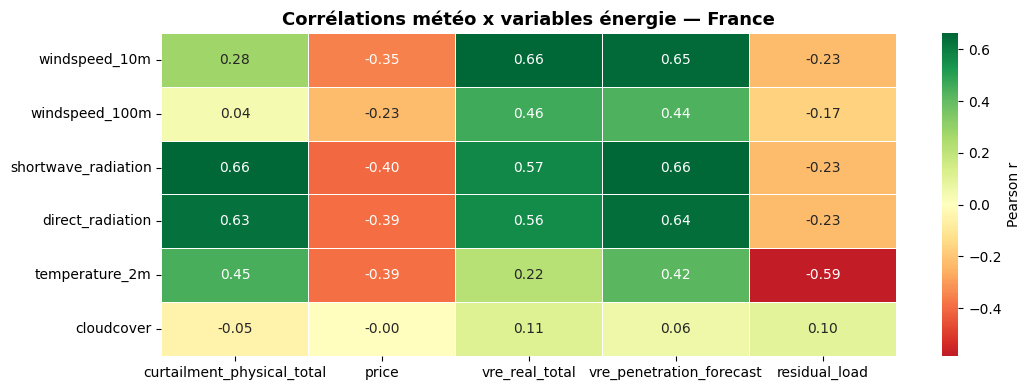

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Les variables météo restent les mêmes
weather_vars = [
    'windspeed_10m', 'windspeed_100m', 'shortwave_radiation',
    'direct_radiation', 'temperature_2m', 'cloudcover'
]

# MISE À JOUR : On utilise notre nouvelle variable d'écrêtement
energy_targets = [
    c for c in [
        'curtailment_physical_total', # <-- La nouvelle variable clé !
        'price', 'vre_real_total', 
        'vre_penetration_forecast', 'residual_load'
    ]
    if c in df_model.columns
]

# Calcul de la matrice de corrélation croisée
cross_corr = (
    df_model[weather_vars + energy_targets]
    .corr(numeric_only=True)
    .loc[weather_vars, energy_targets]
)

# Création de la figure
fig, ax = plt.subplots(figsize=(11, 4)) # Vous pouvez passer à (12, 5) si les labels se chevauchent
sns.heatmap(
    cross_corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)

# Note : Assurez-vous que la variable COUNTRY est bien définie avant
ax.set_title(
    f"Corrélations météo x variables énergie — {COUNTRY.capitalize()}",
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.show()

In [16]:
# MISE À JOUR : On remplace les deux anciennes variables par la nouvelle
weather_corr = df_model[weather_vars + ['curtailment_physical_total']].corr(numeric_only=True)

print('=== Corrélations météo -> Écrêtement (curtailment_physical_total) ===')
# On trie du plus positif (ce qui cause l'écrêtement) au plus négatif (ce qui l'empêche)
print(weather_corr['curtailment_physical_total'][weather_vars].sort_values(ascending=False).round(3))

=== Corrélations météo -> Écrêtement (curtailment_physical_total) ===
shortwave_radiation    0.66
direct_radiation       0.63
temperature_2m         0.45
windspeed_10m          0.28
windspeed_100m         0.04
cloudcover            -0.05
Name: curtailment_physical_total, dtype: float64


# <u>Plots</u>

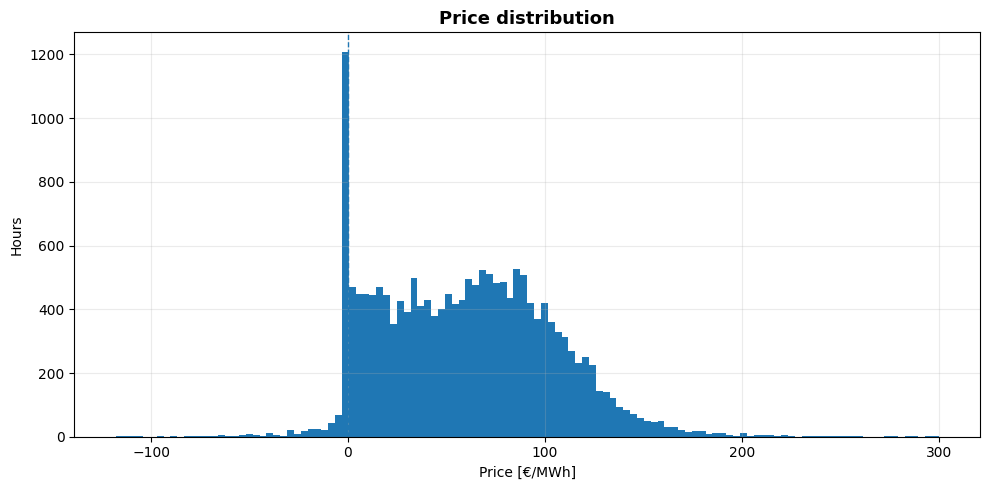

'plots\\curtailment\\france\\price_distribution.png'

In [17]:
# 1. Distribution du prix : Pour montrer la fréquence des prix négatifs (contexte)
pl.plot_price_distribution(df_model, country=COUNTRY)

In [18]:
df_model.columns

Index(['price', 'is_negative', 'load', 'pumped_consumption',
       'residual_load_tso', 'net_export_total', 'generation_load_balance',
       'residual_load', 'nuclear', 'biomass', 'coal', 'gas', 'oil', 'waste',
       'hydro_pumped', 'hydro_ror', 'hydro_res', 'wind_off', 'wind_on',
       'solar', 'wind_total', 'renewable_total', 'thermal_total',
       'vre_real_total', 'price_de_lu', 'price_ch', 'cap_wind_on',
       'cap_wind_off', 'cap_solar', 'cap_biomass', 'cap_nuclear',
       'cap_hydro_ror', 'cap_hydro_res', 'load_forecast', 'load_forecast_j1',
       'wind_off_forecast', 'wind_on_forecast', 'solar_forecast',
       'vre_forecast_total', 'wind_forecast_total', 'residual_load_forecast',
       'vre_penetration_forecast', 'curtailment_raw_gap', 'curtailment_mwh',
       'is_curtailment_likely', 'wind_capacity_factor',
       'solar_capacity_factor', 'hour_sin', 'hour_cos', 'is_weekend',
       'weekday', 'hour', 'windspeed_10m', 'windspeed_100m',
       'shortwave_radiation', 

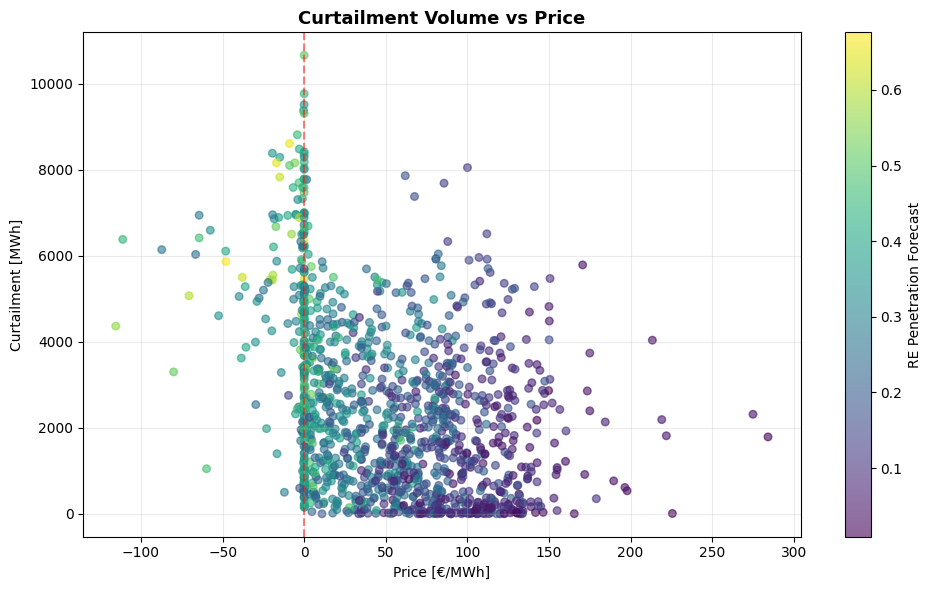

'plots\\curtailment\\france\\curtailment_vs_price.png'

In [19]:
# 2. Corrélation Prix/Curtailment : Pour répondre à 'Under which conditions?' (Économie)
# On s'attend à voir le curtailment exploser quand le prix passe sous 0.
pl.plot_curtailment_v_price_scatter(df_model, country=COUNTRY)

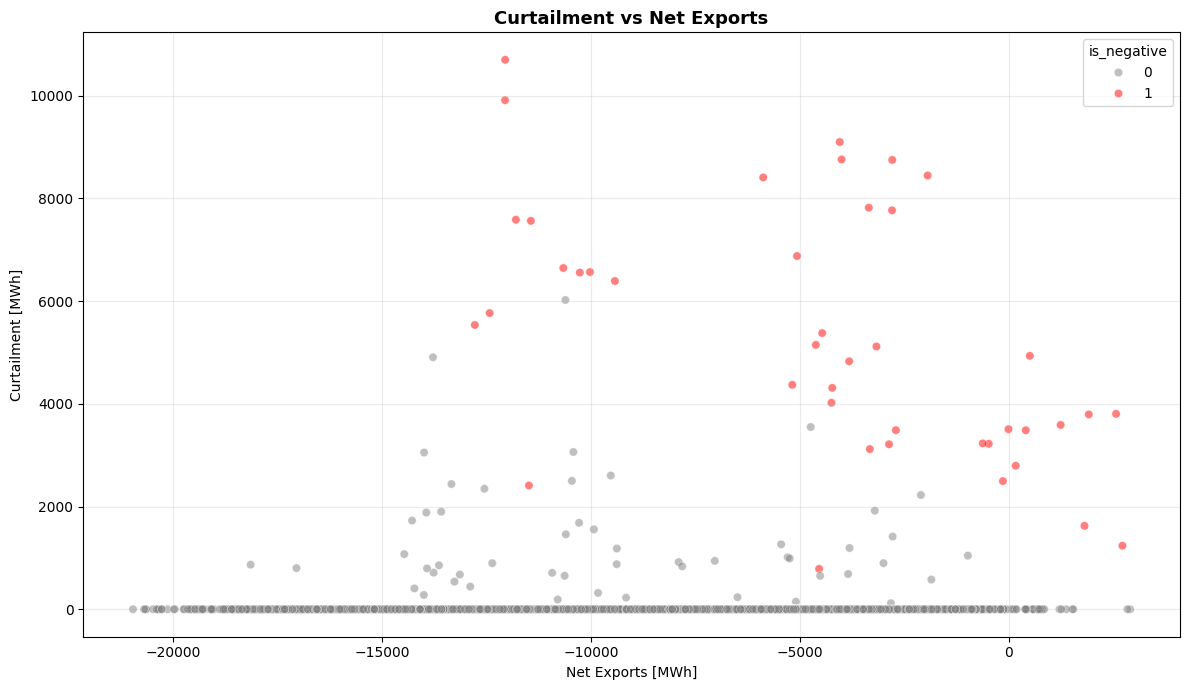

'plots\\curtailment\\france\\export_saturation_logic.png'

In [20]:
# 3. Analyse des Exports : Pour prouver la saturation physique (Réseau)
# On voit si le curtailment n'arrive que quand on exporte déjà au maximum.
pl.plot_export_saturation_curtailment(df_model, country=COUNTRY)

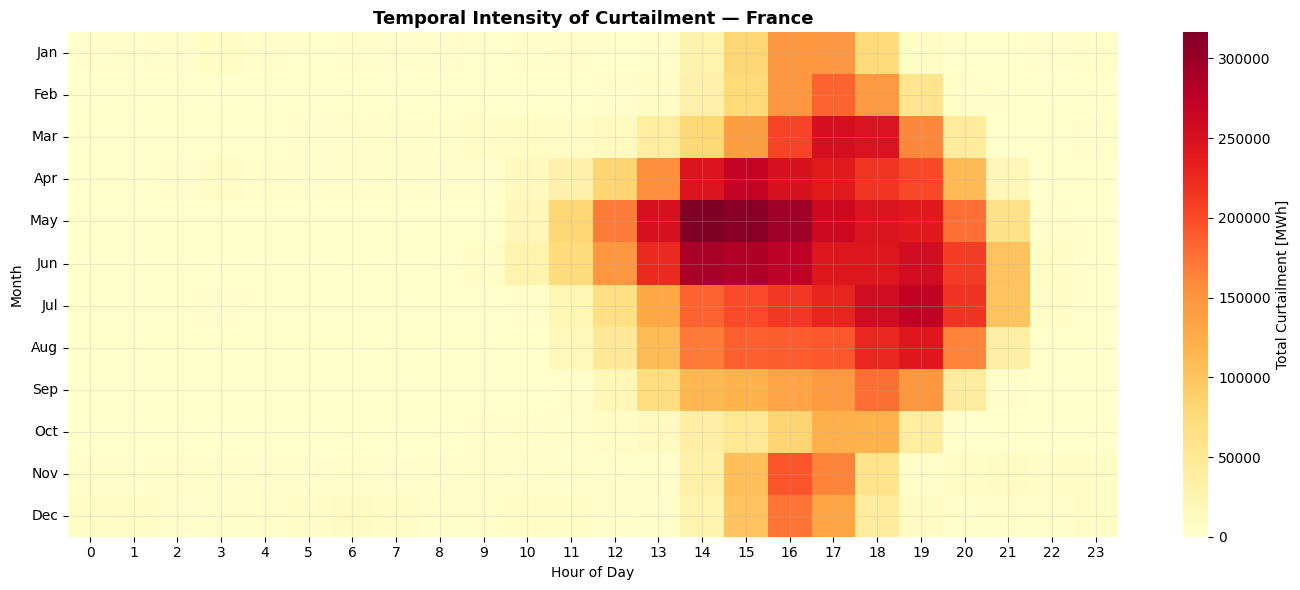

'plots\\curtailment\\france\\curtailment_seasonal_heatmap.png'

In [21]:
# 4. Heatmap saisonnière : Pour répondre à 'How often?' et 'For which renewables?'
# Le solaire apparaîtra l'été à midi, l'éolien l'hiver/nuit.
pl.plot_curtailment_heatmap(df_model, country=COUNTRY)

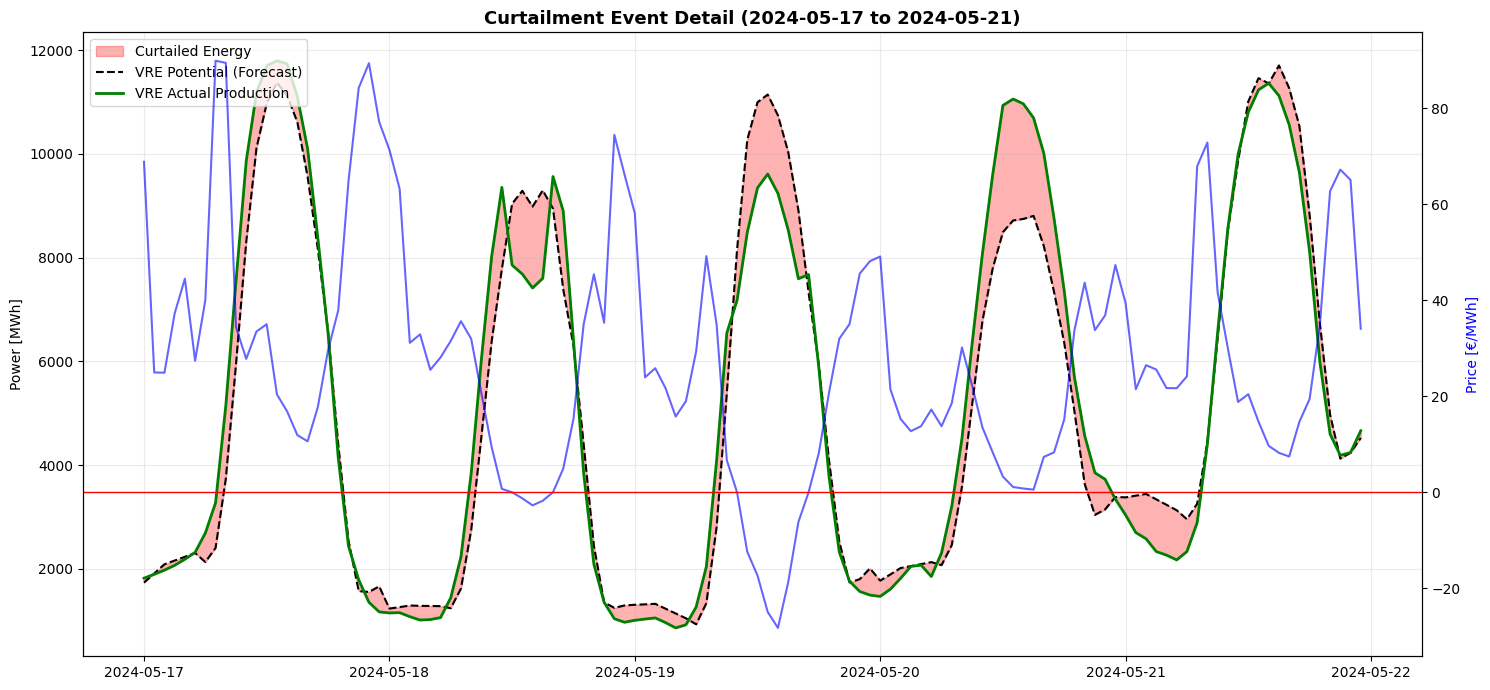

'plots\\curtailment\\france\\curtailment_event_zoom.png'

In [22]:
# 5. Zoom sur un évènement : L'illustration parfaite pour le rapport
# Pentecôte 2024 : week-end prolongé, demande basse + éolien fort
pl.plot_curtailment_event_zoom(df_model, '2024-05-17', '2024-05-21', country=COUNTRY)

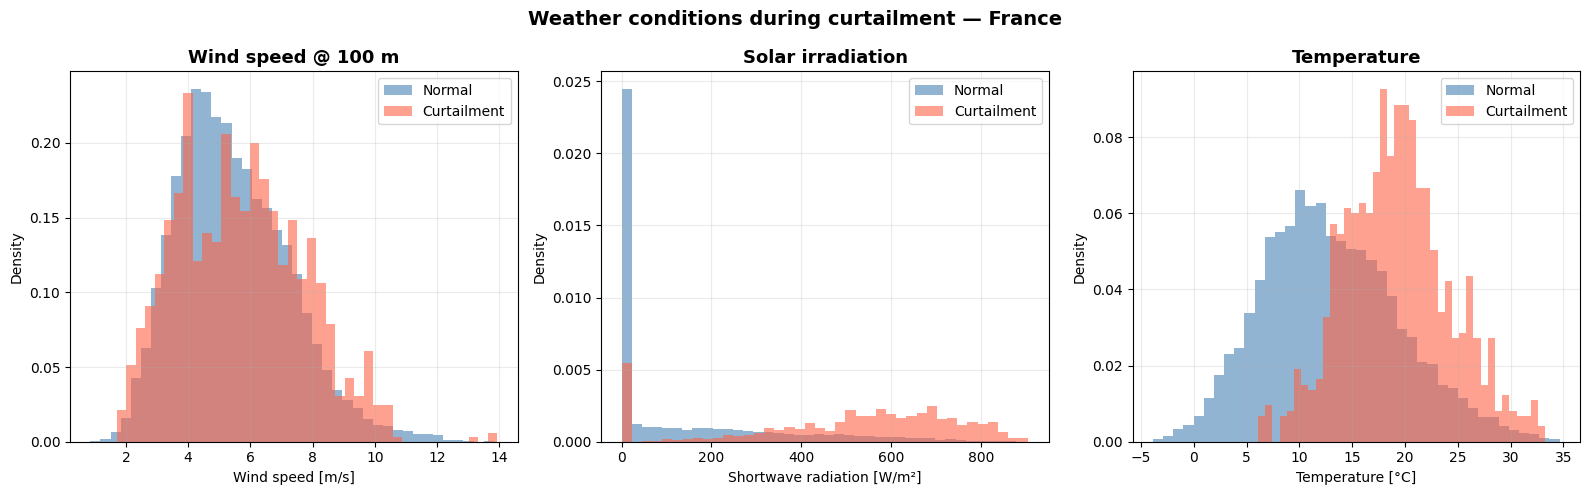

'plots\\curtailment\\france\\weather_curtailment_conditions.png'

In [23]:
# 6. Conditions météo pendant le curtailment vs heures normales
# Répond à : 'Under which conditions?' (météo)
pl.plot_weather_curtailment_conditions(df_model, country=COUNTRY)

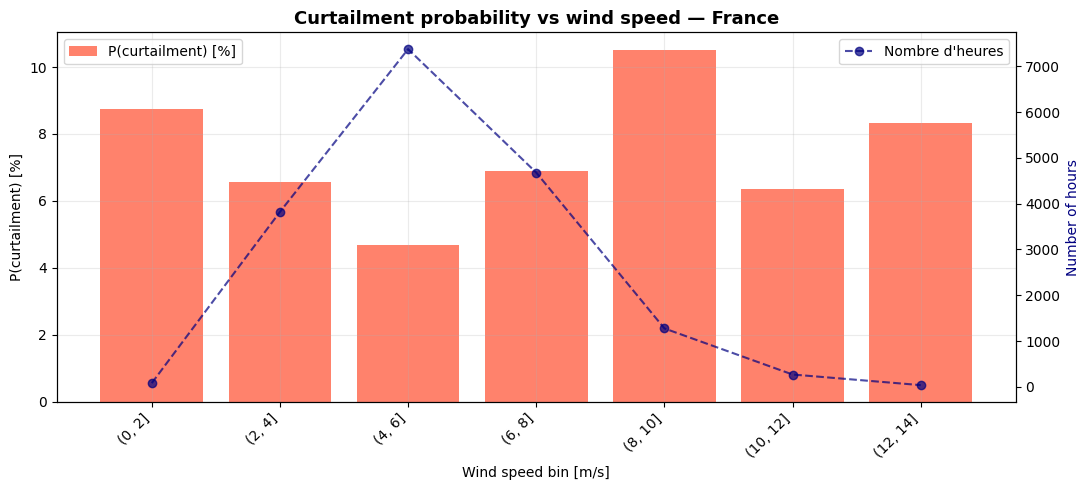

'plots\\curtailment\\france\\curtailment_prob_vs_wind.png'

In [24]:
# 7. Probabilité de curtailment par vitesse de vent (bins de 2 m/s)
# Répond à : 'Under which conditions?' et 'For which renewables?'
pl.plot_curtailment_prob_by_wind(df_model, country=COUNTRY)

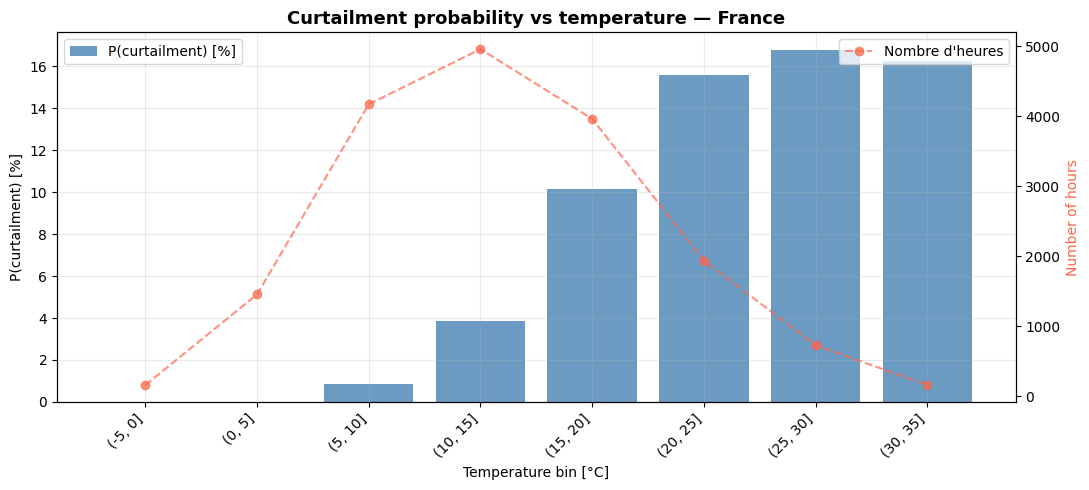

'plots\\curtailment\\france\\curtailment_prob_vs_temperature.png'

In [25]:
# 8. Probabilité de curtailment par tranche de température (5°C)
pl.plot_curtailment_prob_by_temperature(df_model,  country=COUNTRY)

ValueError: The number of FixedLocator locations (11), usually from a call to set_ticks, does not match the number of labels (12).

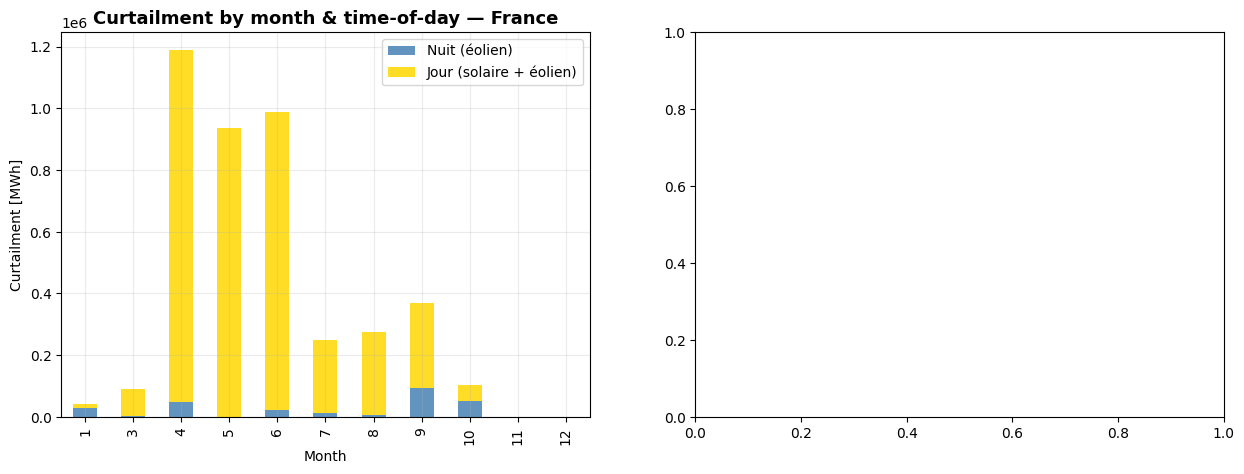

In [26]:
# 9. Décomposition jour/nuit par mois (proxy éolien vs solaire)
# Répond à : 'For which renewables?'
pl.plot_curtailment_by_renewable_type(df_model, country=COUNTRY)

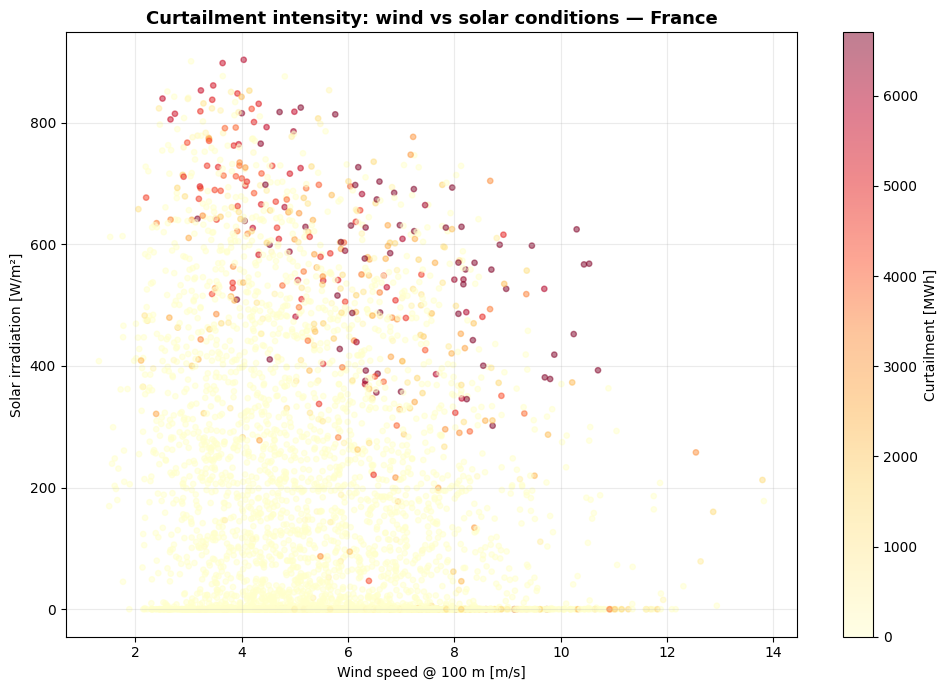

'plots\\curtailment\\france\\curtailment_wind_solar_map.png'

In [ ]:
# 10. Carte 2D vitesse vent × rayonnement solaire, colorée par intensité du curtailment
pl.plot_curtailment_wind_solar_scatter(df_model,  country=COUNTRY)

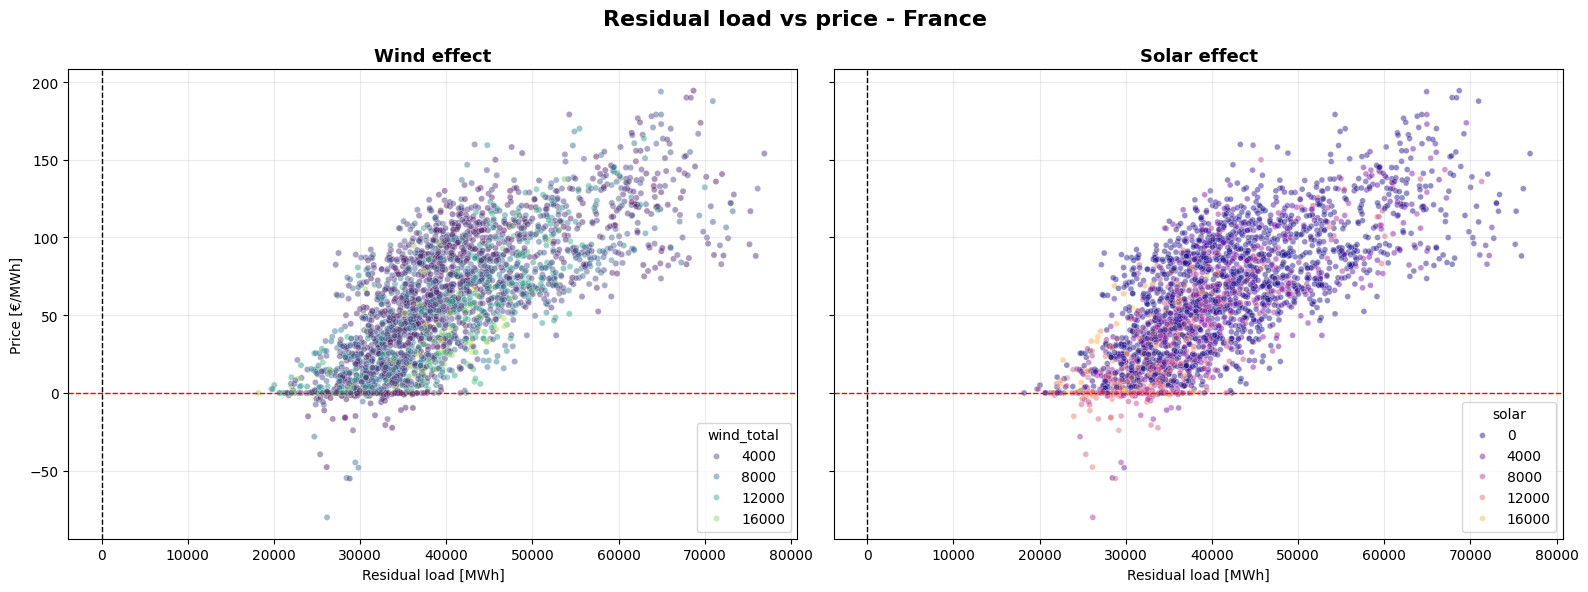

'plots\\curtailment\\france\\residual_load_vs_price_france.png'

In [ ]:
# Analyse offre/demande
pl.plot_residual_load_vs_price(df_model, country=COUNTRY)

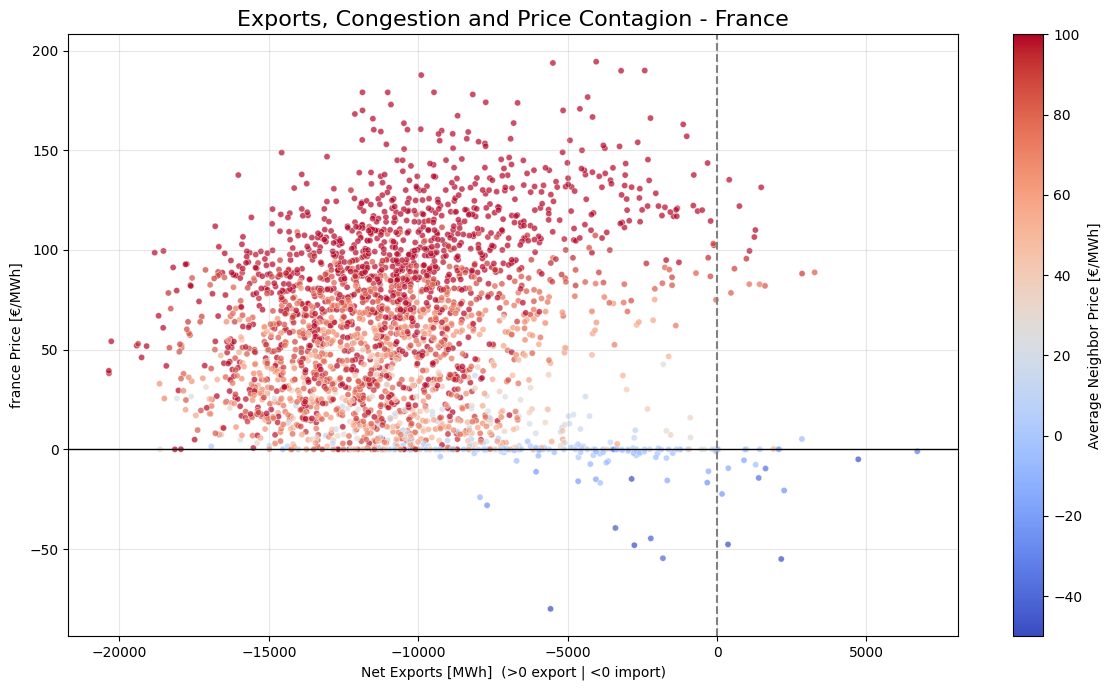

'plots\\curtailment\\france\\exports_and_price_france.png'

In [ ]:
pl.plot_export_congestion_analysis(df_model, country=COUNTRY)

KeyError: 'curtailment_raw_gap'

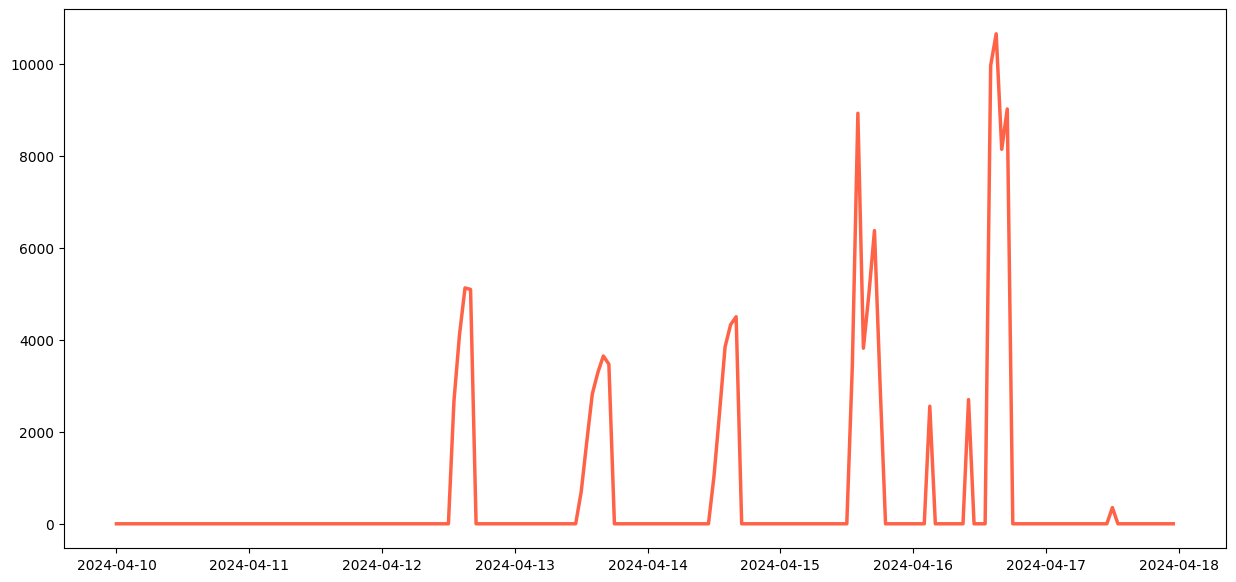

In [ ]:
pl.plot_curtailment_comparison_with_price(
    df_model, 
    start_date="2024-04-10", # Choisis une date avec beaucoup d'écrêtement
    end_date="2024-04-17", 
    country=COUNTRY
)

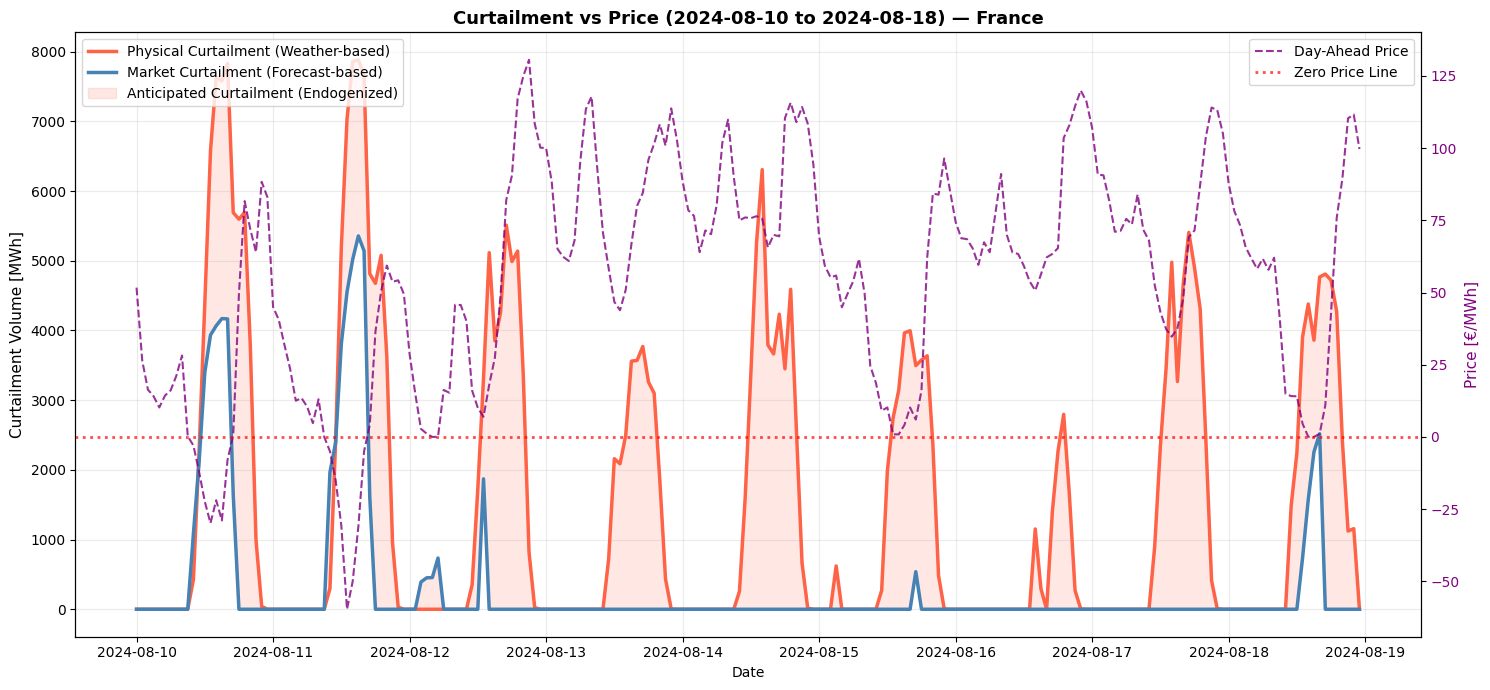

'plots\\curtailment\\france\\curtailment_method_comparison_price.png'

In [ ]:
pl.plot_curtailment_comparison_with_price(
    df_model, 
    start_date="2024-08-10", # Choisis une date avec beaucoup d'écrêtement
    end_date="2024-08-18", 
    country=COUNTRY
)

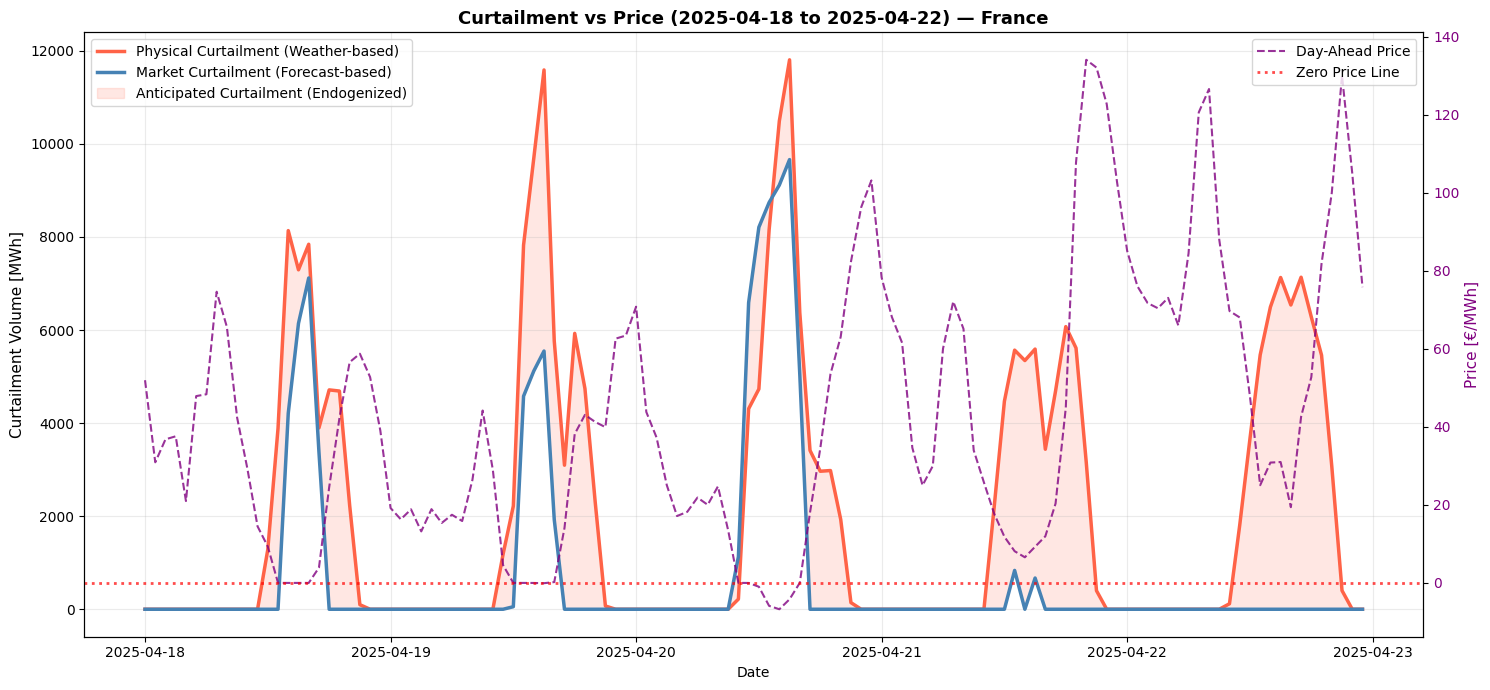

'plots\\curtailment\\france\\curtailment_method_comparison_price.png'

In [ ]:
pl.plot_curtailment_comparison_with_price(
    df_model, 
    start_date="2025-04-18", # Choisis une date avec beaucoup d'écrêtement
    end_date="2025-04-22", 
    country=COUNTRY
)

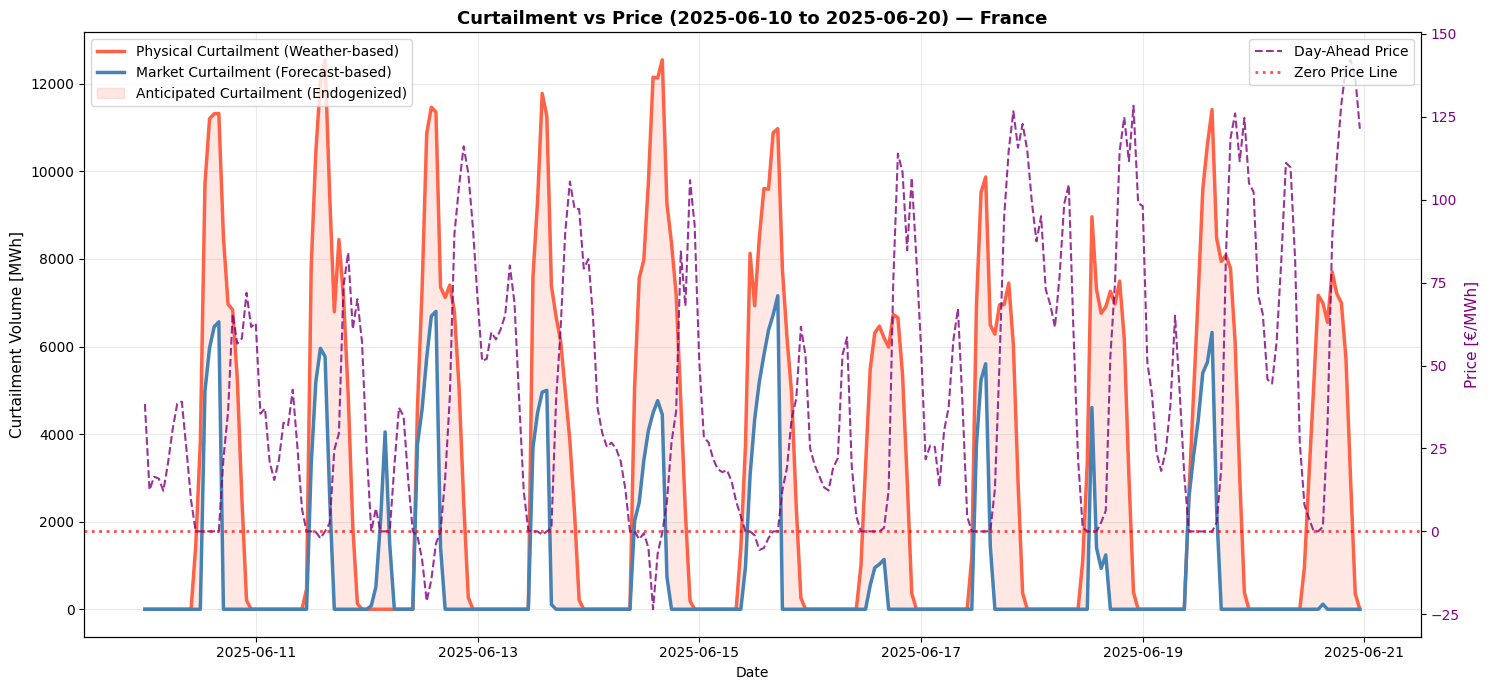

'plots\\curtailment\\france\\curtailment_method_comparison_price.png'

In [ ]:
pl.plot_curtailment_comparison_with_price(
    df_model, 
    start_date="2025-06-10", # Choisis une date avec beaucoup d'écrêtement
    end_date="2025-06-20", 
    country=COUNTRY
)

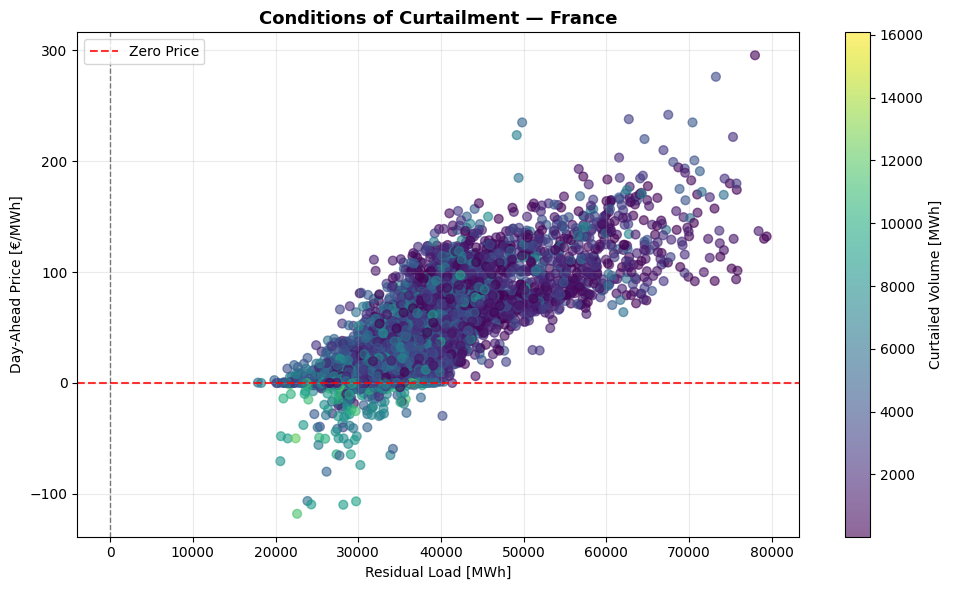

'plots\\curtailment\\france\\curtailment_conditions_scatter.png'

In [ ]:
pl.plot_curtailment_conditions_scatter(df_model, country=COUNTRY)

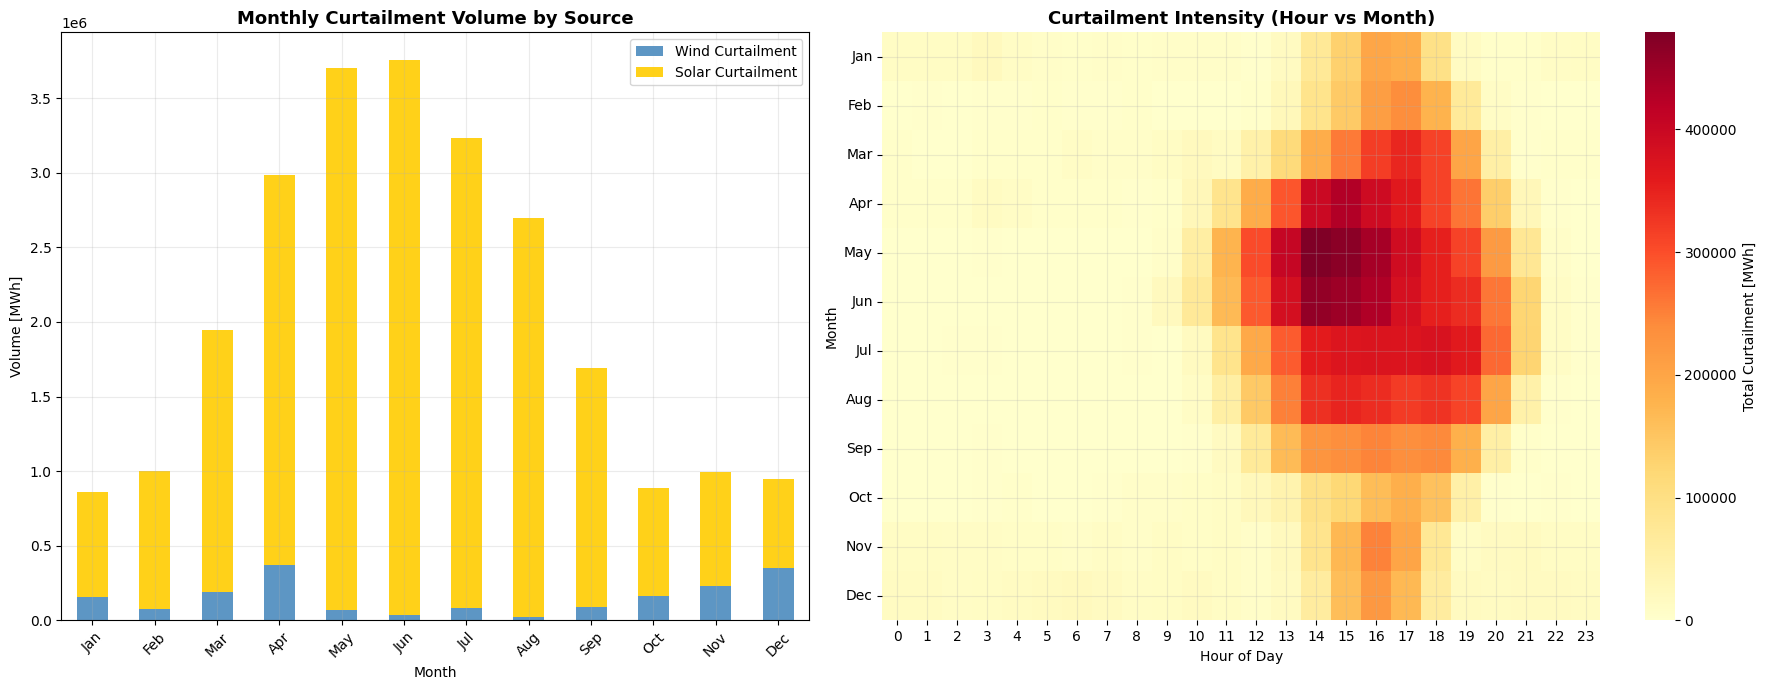

'plots\\curtailment\\france\\combined_curtailment_analysis.png'

In [ ]:
pl.plot_combined_curtailment_analysis(df_model, country=COUNTRY)

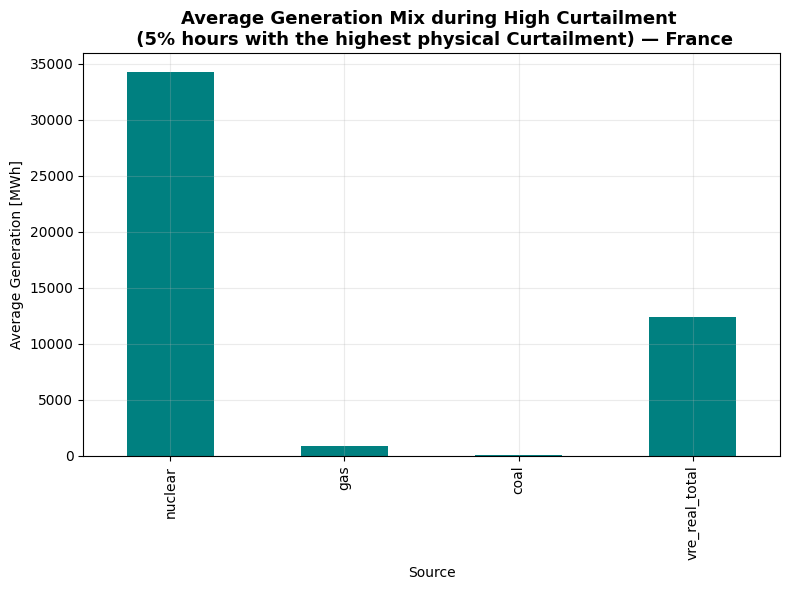

'plots\\curtailment\\france\\mix_during_curtailment_france.png'

In [ ]:
pl.plot_mix_during_curtailment(df_model, country=COUNTRY)

In [ ]:
# Liste des colonnes critiques pour votre modèle
target_cols = [
    'nuclear', 'wind_total', 'solar', 'load', 
    'net_export_total', 'hydro_ror', 'hydro_res', 
    'hydro_pumped', 'biomass'
]

# 1. Nombre de NaNs par colonne
print("--- Valeurs manquantes par colonne ---")
print(df_model[target_cols].isna().sum())

# 2. Nombre total de lignes qui vont être supprimées
rows_with_nan = df_model[target_cols].isna().any(axis=1).sum()
print(f"\nNombre total de lignes avec au moins un NaN : {rows_with_nan} sur {len(df_model)}")

# 3. Voir les dates concernées (souvent des jours entiers ou des passages à l'heure d'été)
if rows_with_nan > 0:
    print("\nDates avec données manquantes (aperçu) :")
    print(df_model[df_model[target_cols].isna().any(axis=1)].index[:10])

--- Valeurs manquantes par colonne ---
nuclear             0
wind_total          0
solar               0
load                1
net_export_total    0
hydro_ror           0
hydro_res           0
hydro_pumped        0
biomass             0
dtype: int64

Nombre total de lignes avec au moins un NaN : 1 sur 17538

Dates avec données manquantes (aperçu) :
DatetimeIndex(['2025-03-30 04:00:00'], dtype='datetime64[ns]', name='Start date', freq=None)


In [ ]:
df_model = df_model.interpolate(method='linear')

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

def generate_nuclear_load_following_table(df_input):
    """
    Replicates Table 1 from Astier & Wolak (2024).
    Analyzes nuclear flexibility relative to VRE production and demand.
    """
    df = df_input.copy()
    
    # --- 1. Variable Preparation (English Names) ---
    df['nuclear_output_GW'] = df['nuclear'] / 1000
    df['vre_output_GW'] = (df['wind_total'] + df['solar']) / 1000
    
    # Residual Demand formula: Load + Net Exports - Hydro - Biomass
    df['residual_demand_no_vre_GW'] = (df['load'] + df['net_export_total'] - 
                                      (df['hydro_ror'] + df['hydro_res'] + df['hydro_pumped']) - 
                                       df['biomass']) / 1000

    # --- 2. Defining System Demand Categories (The Bins) ---
    # Net System Demand = Residual Demand - VRE Production
    df['net_system_demand_GW'] = df['residual_demand_no_vre_GW'] - df['vre_output_GW']
    
    # Thresholds from the paper: <25, 25-40, 40-63, >63
    bins = [-np.inf, 25, 40, 63, np.inf]
    bin_labels = ['VeryLow_lt25', 'Low_25_40', 'Medium_40_63', 'High_gt63']
    df['demand_category'] = pd.cut(df['net_system_demand_GW'], bins=bins, labels=bin_labels)

    # --- 3. Fixed Effects (FE) Identifiers ---
    df['week_fe'] = df.index.to_period('W').astype(str)
    df['day_fe'] = df.index.date.astype(str)
    df['daily_cluster_group'] = df.index.date 

    # --- 4. Model Definitions ---
    # Equation (1): Linear relationship
    eq1 = "nuclear_output_GW ~ vre_output_GW + residual_demand_no_vre_GW"
    
    # Equation (2): Binned/Categorical relationship
    eq2 = ("nuclear_output_GW ~ 0 + demand_category + "
           "demand_category:vre_output_GW + "
           "demand_category:residual_demand_no_vre_GW")

    specifications = [
        (eq1, None),          # (1) No FE
        (eq1, 'week_fe'),     # (2) Week FE
        (eq1, 'day_fe'),      # (3) Day FE
        (eq2, None),          # (4) Binned No FE
        (eq2, 'week_fe'),     # (5) Binned Week FE
        (eq2, 'day_fe')       # (6) Binned Day FE
    ]

    models_results = []

    # --- 5. Running Regressions ---
    print("Running estimations...")
    for formula, fe_col in specifications:
        full_formula = f"{formula} + C({fe_col})" if fe_col else formula
        result = smf.ols(formula=full_formula, data=df).fit(
            cov_type='cluster', 
            cov_kwds={'groups': df['daily_cluster_group']}
        )
        models_results.append(result)

    # --- 6. Formatting the Output Table ---
    # We define which variables we want to show in the final table
    vars_to_show = ['vre_output_GW', 'residual_demand_no_vre_GW']
    for label in bin_labels:
        vars_to_show.append(f"demand_category[{label}]:vre_output_GW")
        vars_to_show.append(f"demand_category[{label}]:residual_demand_no_vre_GW")

    summary_rows = []
    for var in vars_to_show:
        row = [var]
        for res in models_results:
            coeff = res.params.get(var, None)
            std_err = res.bse.get(var, None)
            if coeff is not None:
                row.append(f"{coeff:.3f} ({std_err:.3f})")
            else:
                row.append("-")
        summary_rows.append(row)

    # Creating the final DataFrame
    final_table = pd.DataFrame(summary_rows, columns=["Variable", "(1)", "(2)", "(3)", "(4)", "(5)", "(6)"])
    
    # Adding metadata rows
    metadata = pd.DataFrame([
        ["Week FE"] + ["Yes" if s[1] == 'week_fe' else "No" for s in specifications],
        ["Day FE"] + ["Yes" if s[1] == 'day_fe' else "No" for s in specifications],
        ["R-squared"] + [f"{res.rsquared:.3f}" for res in models_results],
        ["Observations"] + [f"{int(res.nobs)}" for res in models_results]
    ], columns=final_table.columns)

    final_output = pd.concat([final_table, metadata], ignore_index=True)
    
    print("\n" + "="*80)
    print("REPLICATION OF ASTIER & WOLAK - TABLE 1")
    print("="*80)
    print(final_output.to_string(index=False))
    
    return models_results, final_output

# Execution
results_list, formatted_df = generate_nuclear_load_following_table(df_model)

Running estimations...

REPLICATION OF ASTIER & WOLAK - TABLE 1
                                               Variable            (1)            (2)            (3)            (4)            (5)            (6)
                                          vre_output_GW -0.475 (0.026) -0.359 (0.017) -0.290 (0.014)              -              -              -
                              residual_demand_no_vre_GW  0.360 (0.011)  0.073 (0.011) -0.005 (0.012)              -              -              -
            demand_category[VeryLow_lt25]:vre_output_GW              -              -              - -0.471 (0.032) -0.458 (0.023) -0.355 (0.018)
demand_category[VeryLow_lt25]:residual_demand_no_vre_GW              -              -              -  0.317 (0.020)  0.128 (0.016)  0.011 (0.016)
               demand_category[Low_25_40]:vre_output_GW              -              -              - -0.461 (0.056) -0.251 (0.025) -0.136 (0.018)
   demand_category[Low_25_40]:residual_demand_no_vre_GW     

In [ ]:
formatted_df

,Variable,(1),(2),(3),(4),(5),(6)
0,vre_output_GW,-0.475 (0.026),-0.359 (0.017),-0.290 (0.014),-,-,-
1,residual_demand_no_vre_GW,0.360 (0.011),0.073 (0.011),-0.005 (0.012),-,-,-
2,demand_category[VeryLow_lt25]:vre_output_GW,-,-,-,-0.471 (0.032),-0.458 (0.023),-0.355 (0.018)
3,demand_category[VeryLow_lt25]:residual_demand_...,-,-,-,0.317 (0.020),0.128 (0.016),0.011 (0.016)
4,demand_category[Low_25_40]:vre_output_GW,-,-,-,-0.461 (0.056),-0.251 (0.025),-0.136 (0.018)
5,demand_category[Low_25_40]:residual_demand_no_...,-,-,-,0.462 (0.044),0.073 (0.025),-0.005 (0.017)
6,demand_category[Medium_40_63]:vre_output_GW,-,-,-,-0.188 (0.068),-0.107 (0.030),-0.055 (0.018)
7,demand_category[Medium_40_63]:residual_demand_...,-,-,-,0.112 (0.042),0.011 (0.019),0.011 (0.006)
8,demand_category[High_gt63]:vre_output_GW,-,-,-,-0.161 (0.102),-0.045 (0.124),0.034 (0.032)
9,demand_category[High_gt63]:residual_demand_no_...,-,-,-,0.181 (0.097),-0.037 (0.135),-0.055 (0.042)


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

def generate_nuclear_load_following_table(df_input):
    """
    Replicates Table 1 from Astier & Wolak (2024) using available dataset columns.
    """
    df = df_input.copy()
    
    # Ensure index is datetime for Fixed Effects extraction
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # --- 1. Variable Preparation (Units in GW) ---
    
    
    bins = [-np.inf, 25, 40, 63, np.inf]
    bin_labels = ['lt25', '25_40', '40_63', 'gt63']
    df['bin'] = pd.cut(df['net_system_demand'], bins=bins, labels=bin_labels)

    # --- 3. Fixed Effects & Clustering Groups ---
    df['week_fe'] = df.index.to_period('W').astype(str)
    df['day_fe'] = df.index.strftime('%Y-%m-%d')
    df['cluster_group'] = df['day_fe'] 

    # --- 4. Regression Formulas ---
    # Equation 1: Linear
    eq1 = "Nh ~ RESh + RDh"
    
    # Equation 2: Binned (Non-linear)
    # We use '0 +' to get specific coefficients for every category level
    eq2 = ("Nh ~ 0 + bin + "
           "bin:RESh + "
           "bin:RDh")

    specifications = [
        (eq1, None),      # (1)
        (eq1, 'week_fe'), # (2)
        (eq1, 'day_fe'),  # (3)
        (eq2, None),      # (4)
        (eq2, 'week_fe'), # (5)
        (eq2, 'day_fe')   # (6)
    ]

    models_results = []

    # --- 5. Execution ---
    for formula, fe_col in specifications:
        full_formula = f"{formula} + C({fe_col})" if fe_col else formula
        
        # Note: Using small data subsets for OLS with thousands of dummies (Day FE) 
        # is fine, but for full 2012-2024, consider using linearmodels.PanelOLS 
        # if statsmodels becomes too slow.
        result = smf.ols(formula=full_formula, data=df).fit(
            cov_type='cluster', 
            cov_kwds={'groups': df['cluster_group']}
        )
        models_results.append(result)

    # --- 6. Formatting Table ---
    # Define the mapping of internal names to Table 1 labels
    display_map = {
        'RESh': 'RESh',
        'RDh': 'RDh',
        'bin[lt25]:RESh': 'RESh:bin<25GW',
        'bin[lt25]:RDh': 'RDh:bin<25GW',
        'bin[25_40]:RESh': 'RESh:bin25-40GW',
        'bin[25_40]:RDh': 'RDh:bin25-40GW',
        'bin[40_63]:RESh': 'RESh:bin40-63GW',
        'bin[40_63]:RDh': 'RDh:bin40-63GW',
        'bin[gt63]:RESh': 'RESh:bin>63GW',
        'bin[gt63]:RDh': 'RDh:bin>63GW'
    }

    summary_rows = []
    for internal_name, pretty_name in display_map.items():
        row = [pretty_name]
        for res in models_results:
            coeff = res.params.get(internal_name)
            stderr = res.bse.get(internal_name)
            if coeff is not None:
                row.append(f"{coeff:.3f} ({stderr:.3f})")
            else:
                row.append("-")
        summary_rows.append(row)

    # Metadata rows
    final_table = pd.DataFrame(summary_rows, columns=["Variable", "(1)", "(2)", "(3)", "(4)", "(5)", "(6)"])
    metadata = pd.DataFrame([
        ["Week-of-sample FE"] + ["Yes" if s[1] == 'week_fe' else "No" for s in specifications],
        ["Day-of-sample FE"] + ["Yes" if s[1] == 'day_fe' else "No" for s in specifications],
        ["Observations"] + [f"{int(res.nobs):,}" for res in models_results],
        ["R2"] + [f"{res.rsquared:.3f}" for res in models_results]
    ], columns=final_table.columns)

    return pd.concat([final_table, metadata], ignore_index=True)

In [ ]:
generate_nuclear_load_following_table(df_model)

,Variable,(1),(2),(3),(4),(5),(6)
0,RESh,-0.384 (0.025),-0.353 (0.015),-0.327 (0.013),-,-,-
1,RDh,0.339 (0.010),0.109 (0.008),0.051 (0.008),-,-,-
2,RESh:bin<25GW,-,-,-,-0.402 (0.031),-0.476 (0.020),-0.429 (0.016)
3,RDh:bin<25GW,-,-,-,0.290 (0.019),0.183 (0.013),0.097 (0.012)
4,RESh:bin25-40GW,-,-,-,-0.361 (0.050),-0.242 (0.022),-0.166 (0.016)
5,RDh:bin25-40GW,-,-,-,0.496 (0.034),0.105 (0.019),0.034 (0.012)
6,RESh:bin40-63GW,-,-,-,-0.112 (0.061),-0.086 (0.024),-0.050 (0.016)
7,RDh:bin40-63GW,-,-,-,0.181 (0.035),0.032 (0.017),0.022 (0.010)
8,RESh:bin>63GW,-,-,-,-0.073 (0.116),-0.080 (0.061),-0.043 (0.015)
9,RDh:bin>63GW,-,-,-,-0.038 (0.072),-0.011 (0.057),-0.022 (0.018)


In [27]:
import pandas as pd

def check_methodology_coherence(df):
    """
    Compare l'ancienne méthode (Prévisions + 10€) avec la 
    nouvelle méthode (Physique 0.85 + 0€) pour prouver la cohérence.
    """
    old_col = "curtailment_mwh"
    new_col = "curtailment_physical_economic"
    
    # Sécurité : vérifier que les deux colonnes existent
    if old_col not in df.columns or new_col not in df.columns:
        print("Erreur : Assurez-vous d'avoir exécuté la dernière version de add_features()")
        return
    
    # --- 1. COMPARAISON DES VOLUMES (Les ordres de grandeur) ---
    metrics = {
        "Métrique": [
            "1. Volume Total Écrêté (GWh)",
            "2. Nombre total d'heures impactées",
            "3. Volume moyen par heure d'écrêtement (MWh)",
            "4. Écrêtement Maximum sur une heure (MW)"
        ],
        "Ancienne Méthode (Prévision/10€)": [
            df[old_col].sum() / 1000,
            (df[old_col] > 0).sum(),
            df.loc[df[old_col] > 0, old_col].mean(),
            df[old_col].max()
        ],
        "Nouvelle Méthode (Physique/0€)": [
            df[new_col].sum() / 1000,
            (df[new_col] > 0).sum(),
            df.loc[df[new_col] > 0, new_col].mean(),
            df[new_col].max()
        ]
    }
    
    df_metrics = pd.DataFrame(metrics).set_index("Métrique").round(1)
    
    # --- 2. COMPARAISON DES CORRÉLATIONS (La rationalité) ---
    # Qu'est-ce qui explique le mieux l'écrêtement ?
    target_vars = ["price", "residual_load", "windspeed_100m", "shortwave_radiation"]
    existing_vars = [v for v in target_vars if v in df.columns]
    
    corr_old = df[existing_vars + [old_col]].corr(numeric_only=True)[old_col].drop(old_col)
    corr_new = df[existing_vars + [new_col]].corr(numeric_only=True)[new_col].drop(new_col)
    
    df_corr = pd.DataFrame({
        "Corr. Ancienne Méthode": corr_old,
        "Corr. Nouvelle Méthode": corr_new
    }).round(3)

    # --- AFFICHAGE ---
    print("="*70)
    print(" 📊 VÉRIFICATION DE LA COHÉRENCE MACRO/MICRO")
    print("="*70)
    print(df_metrics)
    print("\n" + "="*70)
    print(" 🔗 VÉRIFICATION DE LA RATIONALITÉ PHYSIQUE/ÉCO (Corrélations de Pearson)")
    print("="*70)
    print(df_corr)
    print("\nInterprétation : La nouvelle méthode est 'plus cohérente' si :")
    print("- Le volume total (GWh) a drastiquement baissé (fin de la surestimation).")
    print("- La corrélation négative avec 'price' et 'residual_load' est plus forte (plus proche de -1).")
    
    return df_metrics, df_corr

# Exécution
metrics, correlations = check_methodology_coherence(df_model)

 📊 VÉRIFICATION DE LA COHÉRENCE MACRO/MICRO
                                              Ancienne Méthode (Prévision/10€)  \
Métrique                                                                         
1. Volume Total Écrêté (GWh)                                           4243.40   
2. Nombre total d'heures impactées                                     1079.00   
3. Volume moyen par heure d'écrêtement (MWh)                           3932.70   
4. Écrêtement Maximum sur une heure (MW)                              16277.10   

                                              Nouvelle Méthode (Physique/0€)  
Métrique                                                                      
1. Volume Total Écrêté (GWh)                                         4217.40  
2. Nombre total d'heures impactées                                    966.00  
3. Volume moyen par heure d'écrêtement (MWh)                         4365.90  
4. Écrêtement Maximum sur une heure (MW)                            